### Build a Neural networks  - Bank Customer

#### Load tensorflow

In [0]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
## 1.Read the dataset

In [0]:
d_path="/content/drive/My Drive/GLLAB/bank.csv"
df_bank = pd.read_csv(d_path)

In [10]:
df_bank.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
RowNumber          10000 non-null int64
CustomerId         10000 non-null int64
Surname            10000 non-null object
CreditScore        10000 non-null int64
Geography          10000 non-null object
Gender             10000 non-null object
Age                10000 non-null int64
Tenure             10000 non-null int64
Balance            10000 non-null float64
NumOfProducts      10000 non-null int64
HasCrCard          10000 non-null int64
IsActiveMember     10000 non-null int64
EstimatedSalary    10000 non-null float64
Exited             10000 non-null int64
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [0]:
## Total 13 fetures and 10000 data avilable in Bank custometer data 

In [13]:
df_bank.set_index('RowNumber')

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
RowNumber,,,,,,,,,,,,,
1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0


In [0]:
## 2. Drop the columns which are unique for all users like IDs (5 points)

In [0]:
df_bank =df_bank.drop(['CustomerId','Surname'],axis=1)

In [0]:
## Converting the Gender Column to Numeric

In [17]:
df_bank['Gender'].value_counts()

Male      5457
Female    4543
Name: Gender, dtype: int64

In [0]:
df_bank['gender_nu']=0

In [0]:
df_bank.loc[(df_bank['Gender']=='Female'), 'gender_nu'] = 1

In [20]:
df_bank.loc[1:10,['Gender','gender_nu']]

,Gender,gender_nu
1,Female,1
2,Female,1
3,Female,1
4,Female,1
5,Male,0
6,Male,0
7,Female,1
8,Male,0
9,Male,0
10,Male,0


In [0]:
from sklearn.preprocessing import LabelEncoder
label_X_country_encoder = LabelEncoder()
df_bank['Geography_cat'] = label_X_country_encoder.fit_transform(df_bank['Geography'])

In [22]:
df_bank[df_bank['Balance']==0.0].count()

RowNumber          3617
CreditScore        3617
Geography          3617
Gender             3617
Age                3617
Tenure             3617
Balance            3617
NumOfProducts      3617
HasCrCard          3617
IsActiveMember     3617
EstimatedSalary    3617
Exited             3617
gender_nu          3617
Geography_cat      3617
dtype: int64

In [23]:
df_bank['Exited'].value_counts()

0    7963
1    2037
Name: Exited, dtype: int64

In [0]:
## There is a imbalance between the two classes and the model will incorrectly learn the classification since the number of people 
## leaving 25.5% and 74.5% people did not exit the bank we could use synthetic data to correct this imbalance

In [0]:
## 3. Distinguish the feature and target set (5 points)

In [0]:
X = df_bank.drop(['Exited','Gender','Geography'],axis=1) # Credit Score through Estimated Salary - features
y = df_bank['Exited'] # Exited target

In [0]:
## 4. Divide the data set into Train and test sets ( 80:20 )

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 0)

print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

Number transactions X_train dataset:  (8000, 11)
Number transactions y_train dataset:  (8000,)
Number transactions X_test dataset:  (2000, 11)
Number transactions y_test dataset:  (2000,)


In [0]:
## 5. Normalize the train and test data (5 points)

In [0]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [0]:
## 6. Initialize & build the model (10 points)   -  Initial Model try

In [32]:
import keras
import tensorflow as tf
tf.set_random_seed(42)
#Initialize Sequential model 1
model1 = tf.keras.models.Sequential()

model1.add(tf.keras.layers.Dense(activation = 'relu', input_dim = 11, units=6, kernel_initializer='uniform'))
model1.add(tf.keras.layers.Dense(activation = 'relu', units=6, kernel_initializer='uniform')) 
model1.add(tf.keras.layers.Dense(activation = 'sigmoid', units=1, kernel_initializer='uniform')) 

from keras import optimizers
sgd = tf.keras.optimizers.SGD(lr=0.03)

Using TensorFlow backend.
W0901 02:43:36.962924 140687405664128 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/keras/initializers.py:119: calling RandomUniform.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [0]:
## 7. Optimize the model (Optional)

In [34]:
#Compile the model
model1.compile(optimizer=sgd, loss='binary_crossentropy', metrics=['accuracy'])
model1.summary()
history_sgd=model1.fit(X_train, y_train, batch_size=10, epochs=150)

W0901 02:43:37.071664 140687405664128 deprecation.py:323] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/nn_impl.py:180: add_dispatch_support.<locals>.wrapper (from tensorflow.python.ops.array_ops) is deprecated and will be removed in a future version.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 6)                 72        
_________________________________________________________________
dense_1 (Dense)              (None, 6)                 42        
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 7         
Total params: 121
Trainable params: 121
Non-trainable params: 0
_________________________________________________________________
Epoch 1/150
8000/8000 [==============================] - 3s 335us/sample - loss: 0.5235 - acc: 0.7952
Epoch 2/150
8000/8000 [==============================] - 2s 210us/sample - loss: 0.5061 - acc: 0.7960
Epoch 3/150
8000/8000 [==============================] - 2s 206us/sample - loss: 0.5060 - acc: 0.7960
Epoch 4/150
8000/8000 [==============================] - 2s 211us/sample - loss: 0

In [0]:
## 8. Predict the results using 0.5 as a threshold (Optional)

In [36]:
y_pred = model1.predict(X_test)
y_pred = (y_pred > 0.5)
test_loss, test_acc = model1.evaluate(x=X_test,y=y_test.values)
print("Accuracy: ",test_acc)
print("Loss: ",test_loss)

2000/2000 [==============================] - 0s 49us/sample - loss: 0.3337 - acc: 0.8655
Accuracy:  0.8655
Loss:  0.33368653762340544


In [0]:
## 9. Print the Accuracy score and confusion matrix (5 points)

Confusion matrix:
 [[1541   54]
 [ 215  190]]


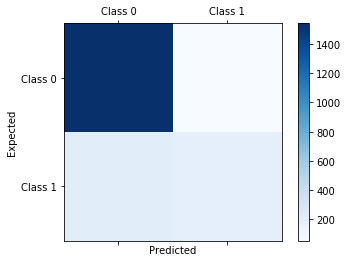

In [38]:
from sklearn.metrics import confusion_matrix
from matplotlib import pyplot as plt

conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred)
print('Confusion matrix:\n', conf_mat)

labels = ['Class 0', 'Class 1']
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.show()

In [0]:
## 10 Graph 

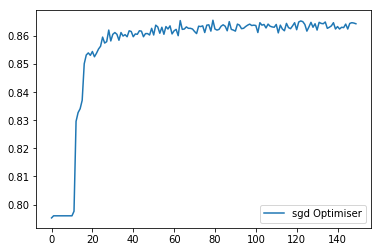

In [40]:
from matplotlib import pyplot
# plot metrics
pyplot.plot(history_sgd.history['acc'],label='sgd Optimiser')

pyplot.legend()

pyplot.show()

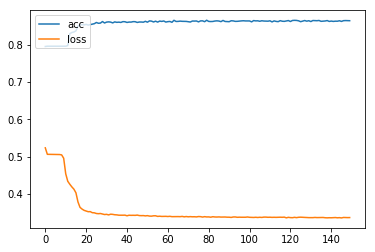

In [41]:
plt.plot(history_sgd.history['acc'])
plt.plot(history_sgd.history['loss'])
plt.legend(['acc', 'loss'], loc='upper left')
plt.show()

In [0]:
# Model 2 try

In [0]:
#Initialize Sequential model 1
model2 = tf.keras.models.Sequential()
model2.add(tf.keras.layers.Dense(activation = 'relu', input_dim = 11, units=6, kernel_initializer='uniform'))
model2.add(tf.keras.layers.Dense(activation = 'relu', units=6, kernel_initializer='uniform')) 
model2.add(tf.keras.layers.Dense(activation = 'relu', units=9, kernel_initializer='uniform'))
model2.add(tf.keras.layers.Dense(activation = 'sigmoid', units=1, kernel_initializer='uniform')) 

In [0]:
model2.compile(optimizer='adam', loss = 'binary_crossentropy', metrics=['accuracy'])

In [45]:
model2.summary()
history_adm=model2.fit(X_train, y_train, batch_size=10, epochs=150)

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_3 (Dense)              (None, 6)                 72        
_________________________________________________________________
dense_4 (Dense)              (None, 6)                 42        
_________________________________________________________________
dense_5 (Dense)              (None, 9)                 63        
_________________________________________________________________
dense_6 (Dense)              (None, 1)                 10        
Total params: 187
Trainable params: 187
Non-trainable params: 0
_________________________________________________________________
Epoch 1/150
8000/8000 [==============================] - 2s 272us/sample - loss: 0.4827 - acc: 0.7954
Epoch 2/150
8000/8000 [==============================] - 2s 279us/sample - loss: 0.4341 - acc: 0.7960
Epoch 3/150
8000/8000 [===========================

In [46]:
y_pred1 = model2.predict(X_test)
y_pred1 = (y_pred > 0.5)
test_loss1, test_acc1 = model2.evaluate(x=X_test,y=y_test.values)
print("Accuracy: ",test_acc1)
print("Loss: ",test_loss1)

2000/2000 [==============================] - 0s 51us/sample - loss: 0.3946 - acc: 0.8470
Accuracy:  0.847
Loss:  0.39455664110183714


Confusion matrix:
 [[1541   54]
 [ 215  190]]


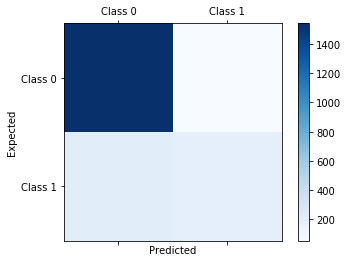

In [47]:

conf_mat = confusion_matrix(y_true=y_test, y_pred=y_pred1)
print('Confusion matrix:\n', conf_mat)

labels = ['Class 0', 'Class 1']
fig = plt.figure()
ax = fig.add_subplot(111)
cax = ax.matshow(conf_mat, cmap=plt.cm.Blues)
fig.colorbar(cax)
ax.set_xticklabels([''] + labels)
ax.set_yticklabels([''] + labels)
plt.xlabel('Predicted')
plt.ylabel('Expected')
plt.show()

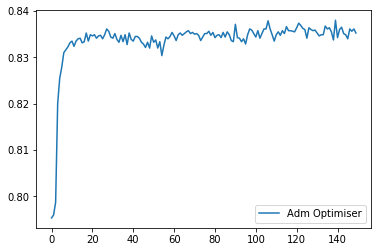

In [49]:
from matplotlib import pyplot
# plot metrics
pyplot.plot(history_adm.history['acc'],label='Adm Optimiser')

pyplot.legend()

pyplot.show()

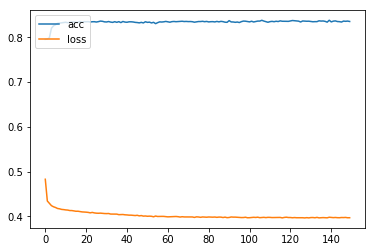

In [50]:
plt.plot(history_adm.history['acc'])
plt.plot(history_adm.history['loss'])
plt.legend(['acc', 'loss'], loc='upper left')
plt.show()

In [0]:
## Conclusion : Look like sgd is doing good job compare to Adm optimisation method. 